In [1]:
import pandas as pd
df = pd.read_csv("/content/Preprocess_Weather_data.csv")
df.sample(10)

,Timestamp,PM2.5,PM10,Carbon_Monoxide_CO,Nitrogen_Dioxide_NO2,Sulphur_Dioxide_SO2,Ozone_O3,European_AQI,Temperature,Humidity,Wind_Speed,Air_Pressure,Rainfall,PM2.5_3h_Mean,PM2.5_3h_Std,PM2.5_6h_Mean,PM2.5_6h_Std,PM2.5_24h_Mean,PM2.5_24h_Std
16827,2024-12-03 02:00:00,14.8,18.7,1766.0,21.8,4.2,65.0,64,10.2,80,5.6,1018.0,0.0,12.633333,1.877054,21.483333,9.983870,29.504167,17.159849
27604,2026-02-25 03:00:00,44.5,46.0,2057.0,50.4,8.8,21.0,71,16.6,49,3.4,1014.7,0.0,36.733333,7.305021,33.483333,5.915206,38.466667,16.222359
24455,2025-10-16 22:00:00,30.6,31.1,614.0,32.8,7.7,46.0,68,19.6,71,4.5,1013.1,0.0,34.400000,3.958535,42.766667,10.271060,35.158333,12.008291
25355,2025-11-23 10:00:00,34.5,38.0,1408.0,30.8,37.8,141.0,94,19.8,40,4.0,1016.7,0.0,34.766667,0.642910,39.916667,7.309286,67.929167,23.275094
12641,2024-06-11 16:00:00,16.5,24.6,606.0,41.0,5.0,77.0,36,30.2,23,8.4,1000.0,0.0,15.166667,1.350309,15.116667,1.566418,17.925000,2.800815
12659,2024-06-12 10:00:00,16.7,26.2,240.0,3.2,7.1,196.0,72,41.2,13,8.9,998.6,0.0,18.466667,1.703917,20.366667,2.386350,17.820833,3.027982
13362,2024-07-11 17:00:00,52.6,88.7,1377.0,97.4,9.5,7.0,75,28.3,81,5.0,995.7,0.0,50.266667,2.640707,44.933333,6.197634,43.370833,3.882791
29224,2026-05-03 15:00:00,27.9,38.2,3014.0,75.2,13.8,51.0,34,25.2,40,9.2,1003.9,0.0,19.100000,8.750429,16.266667,6.720615,16.516667,4.597227
21766,2025-06-26 21:00:00,60.5,60.8,853.0,87.2,10.4,5.0,61,26.0,91,5.1,1003.0,0.0,62.166667,1.650253,56.083333,8.626104,27.791667,17.816917
21030,2025-05-27 05:00:00,28.6,67.1,495.0,6.9,14.4,181.0,69,34.6,34,11.6,1001.8,0.0,28.600000,0.300000,31.750000,4.016342,35.829167,8.945122


In [2]:
!pip install lightgbm xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [3]:
df["AQI_3h_Forecast"] = df["European_AQI"].shift(-3)

In [4]:
df.isnull().sum()

,0
Timestamp,0
PM2.5,0
PM10,0
Carbon_Monoxide_CO,0
Nitrogen_Dioxide_NO2,0
Sulphur_Dioxide_SO2,0
Ozone_O3,0
European_AQI,0
Temperature,0
Humidity,0


In [5]:
df.dropna(inplace=True)

In [11]:
X = df.drop(columns=[
    'Timestamp', 'AQI_3h_Forecast', 'Month', 'Day_Type', 'Hour','European_AQI'
], errors='ignore')

y = df['AQI_3h_Forecast']

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
import joblib

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=0)
}

forecasting_results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name} for 3-Hour Forecasting...")
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    forecasting_results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score (%)": round(r2 * 100, 2)
    })

results_df = pd.DataFrame(forecasting_results).sort_values(by="R2 Score (%)", ascending=False)
print("\nFinal 3-Hour Forecasting Model Comparison Matrix.")
print("="*60)
print(results_df.to_string(index=False))

Training XGBoost for 3-Hour Forecasting...
Training LightGBM for 3-Hour Forecasting...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3983
[LightGBM] [Info] Number of data points in the train set: 24324, number of used features: 17
[LightGBM] [Info] Start training from score 69.255838
Training Random Forest for 3-Hour Forecasting...
Training CatBoost for 3-Hour Forecasting...

Final 3-Hour Forecasting Model Comparison Matrix.
        Model  MAE  RMSE  R2 Score (%)
Random Forest 1.77  3.38         94.65
      XGBoost 1.98  3.63         93.83
     LightGBM 2.00  3.63         93.83
     CatBoost 2.35  4.22         91.65


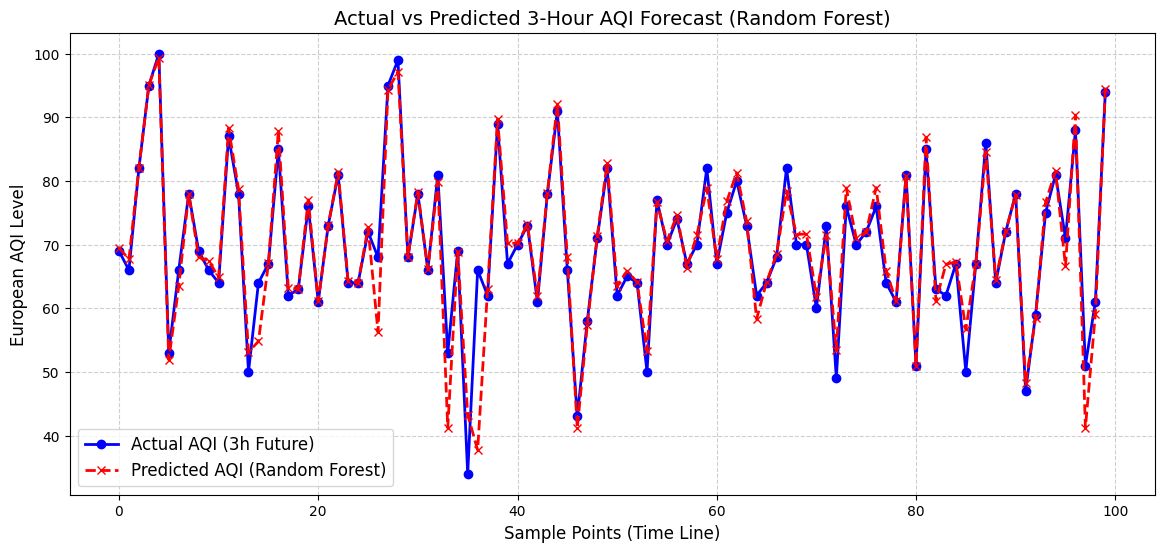

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(14, 6))

plt.plot(y_test.values[:100], label='Actual AQI (3h Future)', color='blue', linewidth=2, marker='o')
plt.plot(y_pred_final[:100], label=f'Predicted AQI ({best_model_name})', color='red', linestyle='--', linewidth=2, marker='x')

plt.title(f"Actual vs Predicted 3-Hour AQI Forecast ({best_model_name})", fontsize=14)
plt.xlabel("Sample Points (Time Line)", fontsize=12)
plt.ylabel("European AQI Level", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [15]:
import joblib
import os

os.makedirs("models", exist_ok=True)

rf_forecaster = trained_models["Random Forest"]
model_save_path = "models/random_forest_3hrsaqi_forecaster.pkl"

joblib.dump(rf_forecaster, model_save_path)

print(f"Model has been saved successfully {model_save_path}")

Model has been saved successfully models/random_forest_3hrsaqi_forecaster.pkl
